# 06 — Analyse d'erreurs et recommandations

**Projet** : Prédiction d'attrition client (churn télécom) avec LightGBM
**Principe** : une métrique globale ne dit **jamais** quoi corriger. Ce notebook descend au
niveau de la ligne : qui le modèle se trompe-t-il, avec quelle confiance, et que fait-on lundi matin ?

Le split de **test** n'est utilisé qu'ici — une seule fois — pour rester une estimation honnête.

## Objectifs pédagogiques

1. Produire une évaluation complète (métriques, matrice, courbes, calibration).
1. Arbitrer le **seuil de décision** avec une table métier (précision / rappel / volume).
1. Segmenter les erreurs pour identifier une cause actionnable.
1. Formuler des recommandations concrètes, appuyées sur les chiffres observés.

**Objectifs transverses du dépôt**

- Comprendre la croissance leaf-wise (`num_leaves`) et son risque de sur-apprentissage face à `max_depth`.
- Armer l'early stopping natif via un callback LightGBM (`early_stopping`, `log_evaluation`) sans réécrire la boucle.
- Régulariser un booster (min_child_samples, subsample + subsample_freq, colsample_bytree, reg_lambda, min_split_gain).

In [1]:
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

# --- Racine du projet ---------------------------------------------------------------------------
# Le notebook s'exécute depuis `notebooks/` : on remonte d'un cran pour pouvoir importer `src`.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hydra import compose, initialize_config_dir  # noqa: E402
from hydra.core.global_hydra import GlobalHydra  # noqa: E402
from loguru import logger  # noqa: E402

from src.schemas.config import validate_config  # noqa: E402
from src.utils.paths import ProjectPaths  # noqa: E402

# --- Réglages d'affichage -----------------------------------------------------------------------
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
logger.remove()
logger.add(sys.stderr, level="WARNING")

# --- Configuration : exactement celle de `python -m src.main` ------------------------------------
# Les notebooks travaillent sur un échantillon réduit (1500 lignes) : l'exécution complète
# reste sous la minute, tout en conservant des distributions réalistes.
NB_ROWS = 1500

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(PROJECT_ROOT / "conf"), version_base=None):
    CONFIG = validate_config(
        compose(
            config_name="config",
            overrides=[
                "mode=train",
                f"data.n_samples={NB_ROWS}",
                "seed=42",
                "log_level=WARNING",
                "++train.epochs=3",
                "train.callbacks.progress_bar=false",
            ],
        )
    )

PATHS = ProjectPaths.from_root(PROJECT_ROOT)
# Les notebooks écrivent leurs artefacts dans `outputs/notebooks` (ignoré par git) afin de ne
# jamais écraser ceux produits par `make train`.
NB_PATHS = ProjectPaths.from_root(PROJECT_ROOT / "outputs" / "notebooks").ensure()

print(f"Projet            : {CONFIG.project.name}")
print(f"Tâche             : {CONFIG.metrics.task}")
print(f"Métrique primaire : {CONFIG.metrics.primary} (seuil cible : 0.7)")
print(f"Cible             : {CONFIG.data.target}")
print(f"Algorithme        : {CONFIG.model.algorithm} ({CONFIG.model.name})")
print(f"Lignes (notebook) : {NB_ROWS}")

Projet            : telecom-churn-lightgbm
Tâche             : binary
Métrique primaire : roc_auc (seuil cible : 0.7)
Cible             : churned
Algorithme        : lightgbm (Gradient boosting LightGBM)
Lignes (notebook) : 1500


In [2]:
from src.data.generators import SyntheticDataGenerator
from src.data.loaders import RawDataLoader

raw_path = PATHS.data_file(CONFIG.data.dataset_name)
if raw_path.exists():
    # Cas nominal : le dataset a été généré par `make data`, on passe par le loader validant.
    raw = RawDataLoader(PATHS, dataset_name=CONFIG.data.dataset_name).load()
    print(f"Dataset lu depuis {raw_path.relative_to(PROJECT_ROOT)}")
else:
    # Le notebook reste exécutable sur un clone frais : on génère en mémoire.
    raw = SyntheticDataGenerator(n_samples=NB_ROWS, seed=CONFIG.data.seed).generate()
    print("data/raw vide : génération synthétique en mémoire (`make data` la persiste)")

raw = raw.head(NB_ROWS).reset_index(drop=True)
print(f"shape = {raw.shape}")
raw.head()

2026-09-13 06:04:27 | INFO     | src.data.loaders:_log_profile:183 - Loaded raw data | rows=4000 cols=15 missing_cells=317 memory=631.8 KB


Dataset lu depuis data/raw/telecom_churn.parquet
shape = (1500, 15)


,customer_id,signup_date,tenure_months,contract_type,internet_service,payment_method,region,monthly_charges,total_charges,support_tickets_6m,avg_monthly_data_gb,num_products,has_promotion,satisfaction_score,churned
0,CUS-00001,2024-12-21,13,two_year,dsl,electronic_check,south,51.89,680.43,1,83.89,2,0,7.57,0
1,CUS-00002,2022-05-03,45,two_year,dsl,credit_card,south,40.44,1849.09,0,138.90,3,0,7.41,0
2,CUS-00003,2023-07-21,30,two_year,none,mailed_check,west,20.11,606.84,1,3.18,5,0,7.48,0
3,CUS-00004,2025-12-01,2,month_to_month,dsl,credit_card,west,49.56,100.25,0,54.37,3,1,5.78,1
4,CUS-00005,2025-08-12,5,month_to_month,fiber,electronic_check,west,84.84,406.24,1,161.71,3,0,5.67,1


In [3]:
from src.data.loaders import DatasetSplitter, feature_target_split
from src.features.build_features import FeatureBuilder, select_feature_columns, split_by_dtype
from src.preprocessing.pipelines import PreprocessingPipeline


def prepare_matrices(frame: pd.DataFrame, config: Any) -> dict[str, Any]:
    """Reproduce what ``TrainPipeline`` does, on the notebook-sized dataset.

    La fonction reprend **exactement** l'enchaînement de production : split → feature
    engineering (appris sur train uniquement) → preprocessing (appris sur train uniquement).
    C'est ce qui rend les chiffres de ce notebook comparables à ceux de `make train`.

    Args:
        frame: Raw dataset.
        config: Validated application configuration.

    Returns:
        Mapping with splits, fitted objects and model-ready matrices.
    """
    target = config.data.target
    drop_columns = list(config.data.drop_columns)

    splitter = DatasetSplitter.from_config(config.model_dump(), seed=config.seed)
    splits = splitter.split(frame, target=target)

    builder = FeatureBuilder.from_config(config.model_dump(), target=target)
    if builder.recipes:
        builder.fit(splits.train)
    enriched = {
        "train": builder.transform(splits.train),
        "val": None if splits.val is None else builder.transform(splits.val),
        "test": builder.transform(splits.test),
    }

    train_frame = enriched["train"]
    feature_columns = select_feature_columns(train_frame, drop_columns=drop_columns, target=target)
    numeric, categorical = split_by_dtype(train_frame, feature_columns)
    explicit = config.preprocessing.model_dump().get("columns") or {}
    numeric = list(explicit.get("numeric") or numeric)
    categorical = list(explicit.get("categorical") or categorical)

    pipeline = PreprocessingPipeline(
        numeric_features=numeric,
        categorical_features=categorical,
        config=config.preprocessing.model_dump(),
        target=target,
    )
    X_train_frame, y_train = feature_target_split(train_frame, target, drop_columns)
    X_train = pipeline.fit_transform(X_train_frame, y_train)

    def project(split: pd.DataFrame | None) -> tuple[pd.DataFrame | None, Any]:
        if split is None:
            return None, None
        _, labels = feature_target_split(split, target, drop_columns)
        return pipeline.transform(split.loc[:, X_train_frame.columns]), labels

    X_val, y_val = project(enriched["val"])
    X_test, y_test = project(enriched["test"])

    return {
        "splits": splits,
        "enriched": enriched,
        "builder": builder,
        "pipeline": pipeline,
        "numeric": numeric,
        "categorical": categorical,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "feature_names": list(pipeline.feature_names_out),
    }


PREPARED = prepare_matrices(raw, CONFIG)
print("train :", PREPARED["X_train"].shape)
print("val   :", None if PREPARED["X_val"] is None else PREPARED["X_val"].shape)
print("test  :", PREPARED["X_test"].shape)
print(f"features livrées au modèle : {len(PREPARED['feature_names'])}")
PREPARED["X_train"].head()

2026-09-13 06:04:28 | INFO     | src.data.loaders:split:505 - Split (random) | train=975 val=225 test=300 | stratify=True


2026-09-13 06:04:28 | INFO     | src.features.build_features:fit:257 - FeatureBuilder fitted | recipes=7 learned=['charges_by_contract', 'tenure_bucket']


2026-09-13 06:04:28 | INFO     | src.preprocessing.pipelines:fit:318 - Fitting preprocessing | rows=975 numeric=17 categorical=4 encoder=onehot scaler=standard


2026-09-13 06:04:28 | INFO     | src.preprocessing.pipelines:fit:332 - Preprocessing fitted | output_features=31


train : (975, 31)
val   : (225, 31)
test  : (300, 31)
features livrées au modèle : 31


,tenure_months,monthly_charges,total_charges,support_tickets_6m,avg_monthly_data_gb,num_products,has_promotion,satisfaction_score,charges_per_tenure,tickets_per_product,tenure_bucket,heavy_data_user,low_satisfaction,charges_by_contract,signup_year,signup_month,signup_quarter,contract_type_month_to_month,contract_type_one_year,contract_type_two_year,internet_service_dsl,internet_service_fiber,internet_service_none,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,region_east,region_north,region_south,region_west
0,-0.454667,-0.376656,-0.100429,-0.936103,-0.677167,1.815339,-0.554049,0.352466,-0.338491,-0.862593,-0.385793,-0.4381,-0.111629,-0.909537,0.226664,1.318529,1.347130,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.947387,-1.777863,-2.166664,-0.936103,-1.189225,-0.636123,1.804894,0.676763,-0.187523,-0.862593,-1.262595,-0.4381,-0.111629,-0.878735,0.845706,0.737351,0.456654,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.898115,0.669337,-0.794432,-0.036004,-0.161837,-0.636123,-0.554049,0.268389,0.997783,0.066669,-1.262595,-0.4381,-0.111629,-0.909537,0.845706,0.446762,0.456654,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.602483,-1.920453,-1.320154,-0.936103,-1.184157,-0.636123,-0.554049,-0.464283,-0.617402,-0.862593,-0.385793,-0.4381,-0.111629,-0.878735,0.845706,-1.296772,-1.324298,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.185869,-0.129265,0.611829,-0.936103,-0.739353,0.998185,-0.554049,0.760840,-0.552362,-0.862593,0.491009,-0.4381,-0.111629,-0.878735,-0.392377,1.027940,1.347130,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:
from src.models import build_model

MODEL = build_model(CONFIG, feature_names=PREPARED["feature_names"])
FIT_RESULT = MODEL.fit(
    PREPARED["X_train"],
    PREPARED["y_train"],
    X_val=PREPARED["X_val"],
    y_val=PREPARED["y_val"],
    callbacks=[],
)
print(MODEL.summary())
pd.Series(FIT_RESULT.metrics, name="métrique").to_frame("valeur")

2026-09-13 06:04:28 | INFO     | src.models.model:_build_estimator:249 - Estimator LGBMClassifier | task=binary params={'boosting_type': 'gbdt', 'subsample_freq': 1, 'n_estimators': 500, 'num_leaves': 31, 'max_depth': -1, 'learning_rate': 0.06, 'min_child_samples': 20, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.0, 'min_split_gain': 0.0, 'importance_type': 'gain', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}


2026-09-13 06:04:28 | INFO     | src.models.factory:build_model:127 - Model built | LightGBMModel(algorithm=lightgbm, boosting=gbdt, rounds=500, num_leaves=31, task=binary, features=31, state=not fitted)


2026-09-13 06:04:28 | INFO     | src.models.model:_build_estimator:249 - Estimator LGBMClassifier | task=binary params={'boosting_type': 'gbdt', 'subsample_freq': 1, 'n_estimators': 500, 'num_leaves': 31, 'max_depth': -1, 'learning_rate': 0.06, 'min_child_samples': 20, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.0, 'min_split_gain': 0.0, 'importance_type': 'gain', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}


2026-09-13 06:04:28 | INFO     | src.models.model:_apply_class_weight:478 - scale_pos_weight='auto' résolu à 2.7938 (négatifs/positifs)


2026-09-13 06:04:28 | INFO     | src.models.model:fit:404 - Model fitted in 0.09s | {'fit_seconds': 0.09011800799999037, 'n_boosting_rounds': 500.0, 'best_iteration': 59.0, 'best_validation_score': 0.8736981825607515}


LightGBMModel(algorithm=lightgbm, boosting=gbdt, rounds=500, num_leaves=31, task=binary, features=31, state=fitted)


,valeur
fit_seconds,0.090118
n_boosting_rounds,500.000000
best_iteration,59.000000
best_validation_score,0.873698


## 1. Évaluation sur le split de test

In [5]:
from src.evaluation.evaluator import Evaluator

EVALUATOR = Evaluator.from_config(MODEL, CONFIG.model_dump(), NB_PATHS)
RESULT = EVALUATOR.evaluate(
    PREPARED["X_test"],
    PREPARED["y_test"],
    split="test",
    context=PREPARED["enriched"]["test"],
)

metrics_frame = pd.DataFrame(
    {"métrique": list(RESULT.metrics), "valeur": [RESULT.metrics[name] for name in RESULT.metrics]}
)
print(f"observations évaluées : {RESULT.n_samples} | taux d'erreur : {RESULT.error_rate:.2%}")
metrics_frame.round(4)

2026-09-13 06:04:28 | INFO     | src.evaluation.evaluator:evaluate:233 - Evaluation on 'test' | n=300 roc_auc=0.86345 error_rate=0.200


observations évaluées : 300 | taux d'erreur : 20.00%


,métrique,valeur
0,roc_auc,0.8635
1,pr_auc,0.7149
2,accuracy,0.8000
3,balanced_accuracy,0.7829
4,precision,0.5960
5,recall,0.7468
6,f1,0.6629
7,log_loss,0.4189


**Ce qu'il faut retenir**

- La métrique de décision est `roc_auc` = **celle affichée ci-dessus** — c'est elle qui pilote le seuil de qualité.
- Le `context` passé à `evaluate()` permet d'enrichir l'analyse d'erreurs avec les colonnes brutes (identifiants, segments).
- Comparer systématiquement au split de validation : un écart important signale un test trop petit ou une dérive.

## 2. Matrice de confusion et métriques par classe

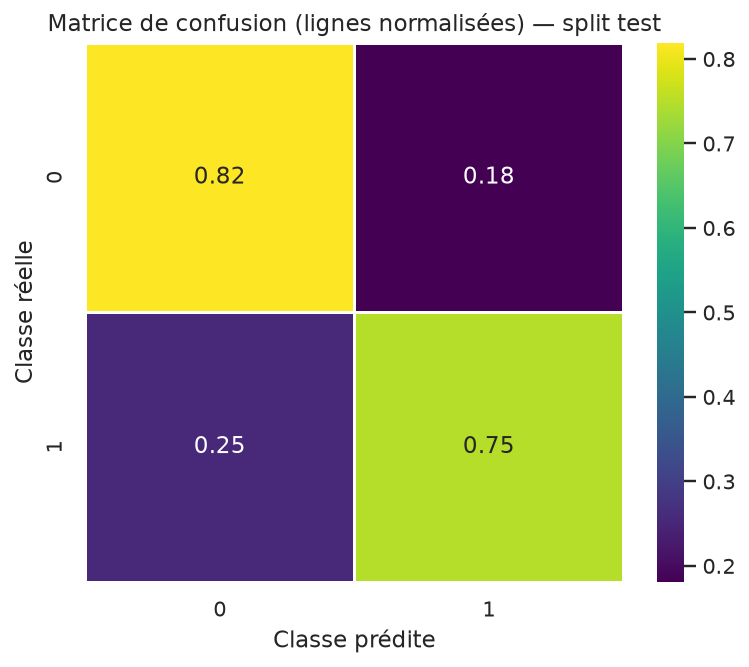

In [6]:
from src.visualization.plots import ClassificationPlots

PLOTS = ClassificationPlots(NB_PATHS.figures_dir)
confusion_path = PLOTS.confusion_matrix(RESULT)
display(Image(confusion_path, width=460))

,class,precision,recall,f1,support,predicted_support,under_prediction
0,0,0.9005,0.8190,0.8578,221,201,20
1,1,0.5960,0.7468,0.6629,79,99,-20


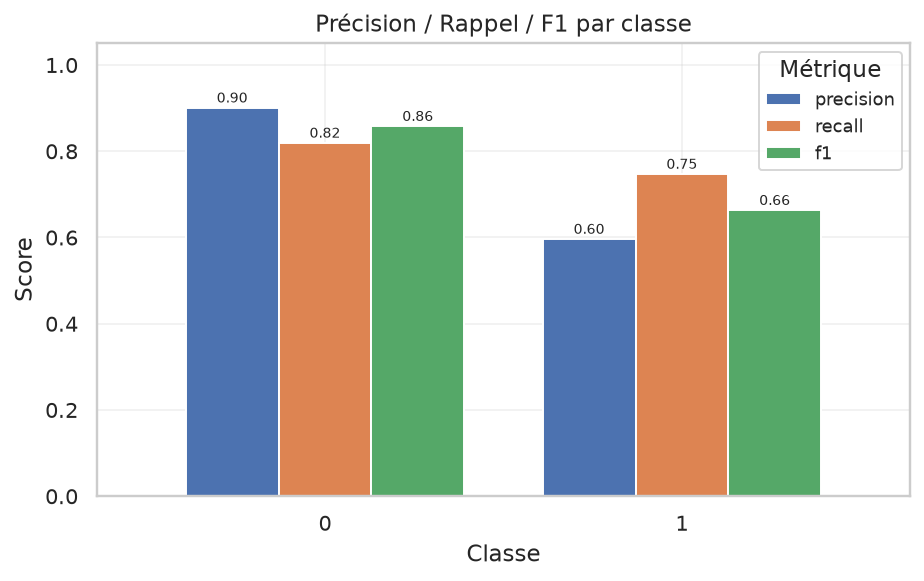

In [7]:
if not RESULT.per_class.empty:
    display(RESULT.per_class.round(4))
    per_class_path = PLOTS.per_class_metrics(RESULT.per_class)
    display(Image(per_class_path, width=520))
else:
    print("Aucune métrique par classe pour cette tâche.")

**Ce qu'il faut retenir**

- Lire la matrice **en lignes** (rappel) puis **en colonnes** (précision) : les deux erreurs ne coûtent pas la même chose.
- Une classe au rappel faible = des cas positifs non détectés ; une précision faible = du bruit envoyé aux équipes.
- Le coût métier asymétrique (faux négatif ≫ faux positif) doit se traduire dans le seuil, pas dans la matrice.

## 3. Courbes et calibration

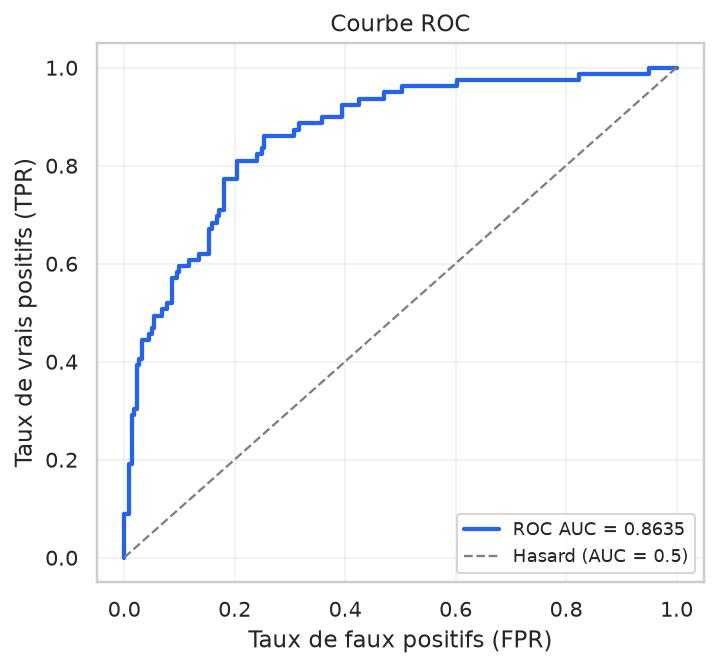

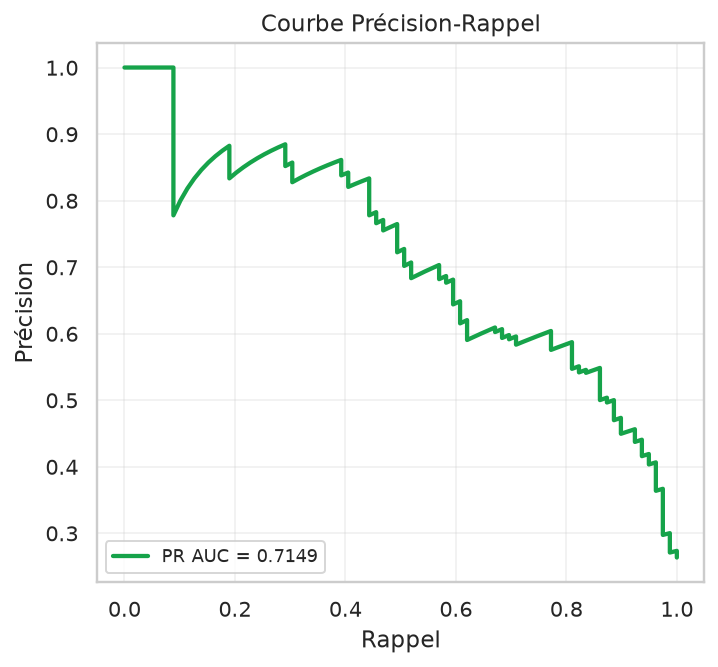

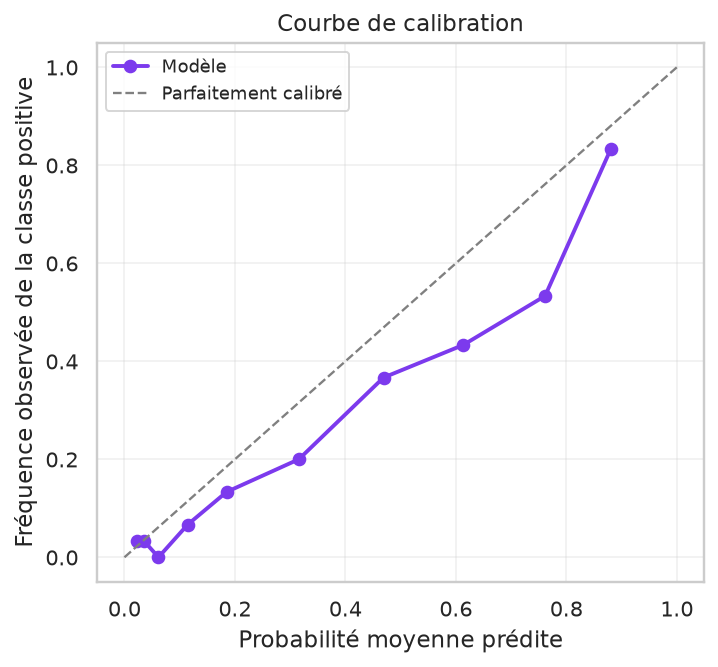

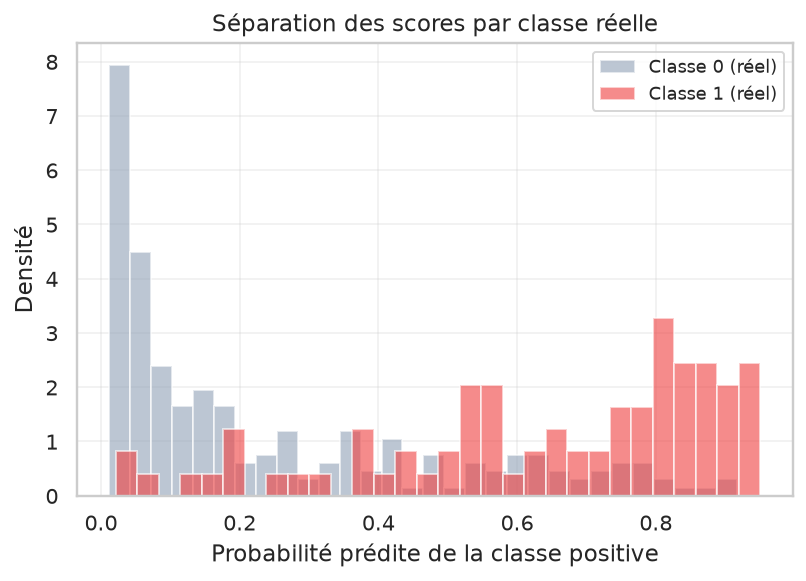

figures générées : ['calibration_curve', 'precision_recall_curve', 'roc_curve', 'score_distribution']


In [8]:
figures = {}
for name in ("roc_curve", "precision_recall_curve", "calibration_curve", "score_distribution"):
    method = getattr(PLOTS, name, None)
    if method is None:
        continue
    path = method(RESULT)
    if path is not None:
        figures[name] = path
        display(Image(path, width=470))
print("figures générées :", sorted(figures))

**Ce qu'il faut retenir**

- Le **ROC AUC** est optimiste en fort déséquilibre : le **PR AUC** reflète mieux la valeur opérationnelle.
- Une courbe de calibration éloignée de la diagonale interdit d'utiliser les probabilités comme des revenus attendus.
- La distribution des scores montre si le seuil par défaut (0.5) tombe dans une zone dense : souvent non.

## 4. Arbitrage du seuil — la table à montrer aux métiers

,threshold,precision,recall,f1,flagged,flagged_rate,true_positives,false_positives,false_negatives
0,0.05,0.3249,0.9747,0.4873,237,0.7900,77,160,2
1,0.10,0.3819,0.9620,0.5468,199,0.6633,76,123,3
2,0.15,0.4181,0.9367,0.5781,177,0.5900,74,103,5
3,0.20,0.4528,0.9114,0.6050,159,0.5300,72,87,7
4,0.25,0.4733,0.8987,0.6201,150,0.5000,71,79,8
5,0.30,0.5036,0.8734,0.6389,137,0.4567,69,68,10
6,0.35,0.5271,0.8608,0.6538,129,0.4300,68,61,11
7,0.40,0.5462,0.8228,0.6566,119,0.3967,65,54,14
8,0.45,0.5833,0.7975,0.6738,108,0.3600,63,45,16
9,0.50,0.5960,0.7468,0.6629,99,0.3300,59,40,20


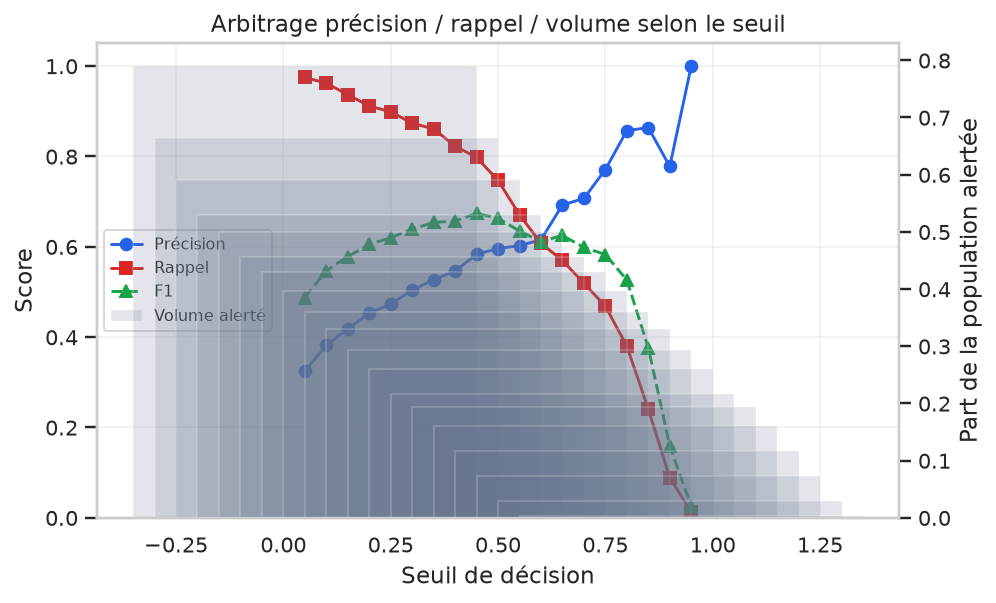

In [9]:
THRESHOLDS = EVALUATOR.threshold_analysis(PREPARED["X_test"], PREPARED["y_test"])
if THRESHOLDS.empty:
    print("Pas de probabilités disponibles : l'arbitrage de seuil ne s'applique pas à ce modèle.")
else:
    display(THRESHOLDS.round(4).head(20))
    threshold_path = PLOTS.threshold_curve(THRESHOLDS)
    if threshold_path is not None:
        display(Image(threshold_path, width=560))

In [10]:
if not THRESHOLDS.empty:
    best_f1 = THRESHOLDS.loc[THRESHOLDS["f1"].idxmax()]
    volume_column = next(
        (name for name in THRESHOLDS.columns if "volume" in name or "flag" in name), None
    )
    print(f"seuil maximisant le F1 : {float(best_f1['threshold']):.2f}")
    print(
        f"  précision = {float(best_f1['precision']):.3f} | rappel = {float(best_f1['recall']):.3f}"
    )
    if volume_column:
        print(f"  {volume_column} = {best_f1[volume_column]}")
    print("\nLecture métier : baisser le seuil augmente le volume à traiter et le rappel ;")
    print("l'augmenter réduit la charge des équipes mais laisse passer des cas positifs.")

seuil maximisant le F1 : 0.45
  précision = 0.583 | rappel = 0.797
  flagged = 108.0

Lecture métier : baisser le seuil augmente le volume à traiter et le rappel ;
l'augmenter réduit la charge des équipes mais laisse passer des cas positifs.


**Ce qu'il faut retenir**

- Le seuil est un **paramètre métier** : il se choisit avec la capacité de traitement disponible, pas à 0.5 par défaut.
- Documenter la table dans le rapport (`ReportBuilder`) évite de re-débattre du seuil à chaque comité.

## 5. Où le modèle se trompe-t-il ?

In [11]:
if RESULT.errors.empty:
    print("Aucune erreur sur le split de test.")
else:
    print(f"{len(RESULT.errors)} erreurs analysées (triées par confiance décroissante)")
    display(RESULT.errors.head(12))

25 erreurs analysées (triées par confiance décroissante)


,customer_id,tenure_months_x,contract_type_x,internet_service_x,payment_method_x,monthly_charges_x,support_tickets_6m_x,satisfaction_score_x,y_true,y_pred,probability_class_0,probability_class_1,probability_positive,confidence,is_error,signup_date,tenure_months_y,contract_type_y,internet_service_y,payment_method_y,region,monthly_charges_y,total_charges,support_tickets_6m_y,avg_monthly_data_gb,num_products,has_promotion,satisfaction_score_y,churned,charges_per_tenure,tickets_per_product,tenure_bucket,heavy_data_user,low_satisfaction,charges_by_contract,signup_year,signup_month,signup_quarter
0,CUS-01186,42,two_year,fiber,credit_card,68.22,0,7.92,1,0,0.978638,0.021362,0.021362,0.978638,1,2022-08-03,42,two_year,fiber,credit_card,north,68.22,2905.56,0,34.84,3,1,7.92,1,1.586512,0.000000,3,0,0,55.589003,2022,8,3
1,CUS-01194,67,two_year,fiber,bank_transfer,58.76,2,7.16,1,0,0.969276,0.030724,0.030724,0.969276,1,2020-07-08,67,two_year,fiber,bank_transfer,west,58.76,3945.29,2,186.04,3,0,7.16,1,0.864118,0.500000,3,0,0,55.589003,2020,7,3
2,CUS-01465,26,two_year,fiber,credit_card,63.56,0,8.70,1,0,0.919697,0.080303,0.080303,0.919697,1,2023-12-03,26,two_year,fiber,credit_card,east,63.56,1686.39,0,40.61,3,0,8.70,1,2.354074,0.000000,2,0,0,55.589003,2023,12,4
3,CUS-00284,3,month_to_month,fiber,bank_transfer,87.14,2,5.74,0,1,0.082485,0.917515,0.917515,0.917515,1,2025-10-09,3,month_to_month,fiber,bank_transfer,east,87.14,267.83,2,71.17,2,0,5.74,0,21.785000,0.666667,0,0,0,57.533634,2025,10,4
4,CUS-00555,8,month_to_month,fiber,electronic_check,64.55,1,6.42,0,1,0.092136,0.907864,0.907864,0.907864,1,2025-05-09,8,month_to_month,fiber,electronic_check,east,64.55,505.29,1,174.68,2,0,6.42,0,7.172222,0.333333,0,0,0,57.533634,2025,5,2
5,CUS-00260,5,month_to_month,fiber,electronic_check,68.69,0,7.10,0,1,0.130364,0.869636,0.869636,0.869636,1,2025-08-26,5,month_to_month,fiber,electronic_check,east,68.69,341.35,0,439.06,3,0,7.10,0,11.448333,0.000000,0,1,0,57.533634,2025,8,3
6,CUS-00100,3,one_year,none,electronic_check,20.37,0,7.06,1,0,0.866202,0.133798,0.133798,0.866202,1,2025-10-14,3,one_year,none,electronic_check,north,20.37,59.02,0,1.20,1,0,7.06,1,5.092500,0.000000,0,0,0,55.559052,2025,10,4
7,CUS-01173,14,month_to_month,none,mailed_check,24.33,0,6.61,1,0,0.850394,0.149606,0.149606,0.850394,1,2024-11-30,14,month_to_month,none,mailed_check,south,24.33,337.82,0,3.68,1,0,6.61,1,1.622000,0.000000,1,0,0,57.533634,2024,11,4
8,CUS-01073,5,two_year,fiber,credit_card,74.13,2,6.57,0,1,0.172093,0.827907,0.827907,0.827907,1,2025-08-26,5,two_year,fiber,credit_card,south,74.13,363.85,2,113.13,1,0,6.57,0,12.355000,1.000000,0,0,0,55.589003,2025,8,3
9,CUS-00656,16,two_year,fiber,electronic_check,78.92,0,7.29,1,0,0.823027,0.176973,0.176973,0.823027,1,2024-09-12,16,two_year,fiber,electronic_check,east,78.92,1287.30,0,67.50,2,0,7.29,1,4.642353,0.000000,1,0,0,55.589003,2024,9,3


In [12]:
# Segmentation des erreurs : quelle population concentre les faux positifs / faux négatifs ?
if not RESULT.errors.empty and CONFIG.data.target:
    error_frame = RESULT.errors.copy()
    segmentation_columns = [
        column
        for column in (
            ["contract_type", "internet_service", "payment_method", "region", "has_promotion"]
        )
        if column in error_frame.columns
    ][:3]
    for column in segmentation_columns:
        grouped = (
            error_frame.groupby(error_frame[column].astype(str))
            .agg(erreurs=("is_error", "size"))
            .sort_values("erreurs", ascending=False)
        )
        total = raw.groupby(raw[column].astype(str)).size().rename("population")
        table = grouped.join(total, how="left")
        table["taux_erreur"] = (table["erreurs"] / table["population"]).round(4)
        print(f"--- erreurs par `{column}` ---")
        display(table.head(6))
else:
    print("Segmentation indisponible pour cette tâche.")

--- erreurs par `region` ---


,erreurs,population,taux_erreur
region,,,
north,9,412,0.0218
east,8,379,0.0211
south,4,365,0.0110
west,4,344,0.0116


--- erreurs par `has_promotion` ---


,erreurs,population,taux_erreur
has_promotion,,,
0,17,1149,0.0148
1,8,351,0.0228


**Ce qu'il faut retenir**

- Un segment dont le taux d'erreur dépasse nettement la moyenne est une **cause**, pas une anecdote.
- Vérifier ensuite le volume de données de ce segment à l'entraînement : sous-représentation = sous-performance.
- Les réponses possibles : feature dédiée, sur-échantillonnage du segment, ou règle métier complémentaire.

In [13]:
baseline_comparison = EVALUATOR.compare_to_baseline(PREPARED["X_test"], PREPARED["y_test"])
gains = pd.DataFrame(
    {
        "modèle": ["modèle entraîné", "baseline"],
        CONFIG.metrics.primary: [
            RESULT.metrics.get(CONFIG.metrics.primary, float("nan")),
            baseline_comparison.get(f"baseline_{CONFIG.metrics.primary}", float("nan")),
        ],
    }
)
gains.round(4)

2026-09-13 06:04:29 | INFO     | src.evaluation.evaluator:compare_to_baseline:267 - Baseline 'dummy' | {'baseline_roc_auc': 0.5, 'baseline_pr_auc': 0.2633333333333333, 'baseline_accuracy': 0.7366666666666667, 'baseline_balanced_accuracy': 0.5, 'baseline_precision': 0.0, 'baseline_recall': 0.0, 'baseline_f1': 0.0, 'baseline_log_loss': 9.491495392467517}


,modèle,roc_auc
0,modèle entraîné,0.8635
1,baseline,0.5000


## 6. Rapport exécutable

In [14]:
from src.evaluation.reports import ReportBuilder

REPORTER = ReportBuilder(NB_PATHS, config=CONFIG.model_dump())
WRITTEN = REPORTER.build(
    RESULT, model=MODEL, thresholds=THRESHOLDS if not THRESHOLDS.empty else None
)
print(f"{len(WRITTEN)} artefacts écrits dans {NB_PATHS.artifacts_dir.relative_to(PROJECT_ROOT)}")
report_path = WRITTEN["report"]
Markdown(report_path.read_text(encoding="utf-8")[:2500] + "\n\n[…]")

2026-09-13 06:04:30 | INFO     | src.visualization.plots:save_all:459 - Figures generated: ['calibration_curve', 'confusion_matrix', 'error_breakdown', 'feature_importance', 'metrics_summary', 'per_class_metrics', 'precision_recall_curve', 'roc_curve', 'score_distribution', 'threshold_tradeoff']


2026-09-13 06:04:30 | INFO     | src.evaluation.reports:build:117 - Rapport généré : /home/user/templates/data-science/classification/with-lightgbm/outputs/notebooks/artifacts/reports/evaluation_report.md


13 artefacts écrits dans outputs/notebooks/artifacts


# Rapport d'évaluation — Prédiction d'attrition client (churn télécom) avec LightGBM

*Généré le 2026-09-13 06:04 UTC · split `test` · 300 observations · cible `churned`*

## 1. Synthèse

| Indicateur | Valeur |
| --- | --- |
| Métrique principale (`roc_auc`) | **0.8635** |
| Taux d'erreur | 20.0% |
| Nombre d'erreurs analysées | 25 |
| Classes | `0`, `1` |
| Modèle | LightGBMModel(algorithm=lightgbm, boosting=gbdt, rounds=500, num_leaves=31, task=binary, features=31, state=fitted) |

## 2. Métriques

| Métrique | Valeur |
| --- | --- |
| `accuracy` | 0.8000 |
| `balanced_accuracy` | 0.7829 |
| `f1` | 0.6629 |
| `log_loss` | 0.4189 |
| `pr_auc` | 0.7149 |
| `precision` | 0.5960 |
| `recall` | 0.7468 |
| `roc_auc` | 0.8635 |

### Détail par classe

| class | precision | recall | f1 | support | predicted_support | under_prediction |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 0.9005 | 0.8190 | 0.8578 | 221 | 201 | 20 |
| 1 | 0.5960 | 0.7468 | 0.6629 | 79 | 99 | -20 |

## 3. Matrice de confusion

| réel \ prédit | 0 | 1 |
| --- | --- | --- |
| **0** | 181 | 40 |
| **1** | 20 | 59 |

![Matrice de confusion](artifacts/figures/confusion_matrix.png)

- **Vrais négatifs** : 181 (60.3%) — clients conservés correctement identifiés.
- **Vrais positifs** : 59 (19.7%) — départs détectés.
- **Faux positifs** : 40 (13.3%) — coût : action de rétention inutile.
- **Faux négatifs** : 20 (6.7%) — coût : client perdu sans action.

## 4. Analyse d'erreurs

25 erreurs parmi 300 observations (20.0%). Les erreurs les plus coûteuses sont celles où le modèle est **confiant et faux** : elles sont listées ci-dessous, triées par confiance décroissante.

| customer_id | tenure_months_x | contract_type_x | internet_service_x | payment_method_x | monthly_charges_x | support_tickets_6m_x | satisfaction_score_x |
| --- | --- | --- | --- | --- | --- | --- | --- |
| CUS-01186 | 42 | two_year | fiber | credit_card | 68.2200 | 0 | 7.9200 |
| CUS-01194 | 67 | two_year | fiber | bank_transfer | 58.7600 | 2 | 7.1600 |
| CUS-01465 | 26 | two_year | fiber | credit_card | 63.5600 | 0 | 8.7000 |
| CUS-00284 | 3 | month_to_month | fiber | bank_transfer | 87.1400 | 2 | 5.7400 |
| CUS-00555 | 8 | month_to_month | fiber | electronic_check | 64.5500 | 1 | 6.4200 |
| CUS-00260 | 5 | month_to_month | fiber | electronic_check | 68.6900 | 0 | 7.1000 |
| CUS-00100 | 3 | one_year | none | electronic_check | 20.3700 | 0 | 7.0600 |
| CUS-01173 | 14 | month_to_month | none | mailed_check | 24.3300 | 0 | 6.61

[…]

**Ce qu'il faut retenir**

- Le rapport mélange **chiffres calculés** et **recommandations documentées** : il est régénérable à chaque run.
- Le même contenu est écrit en JSON (`artifacts/metrics`) pour être consommé par un dashboard ou une CI.

In [15]:
recommendations = REPORTER.recommendations(RESULT)
for index, recommendation in enumerate(recommendations, start=1):
    print(f"{index:2d}. {recommendation}")

 1. Calibration insuffisante pour un usage probabiliste : envelopper le modèle dans un `CalibratedClassifierCV` (sigmoïde ou isotonic).
 2. Comparer cette exécution aux autres stacks du même cas d'usage (mêmes données, mêmes métriques) avant de figer un choix technique.
 3. Piloter le modèle sur le rappel de la classe churn et le coût par alerte, pas sur l'accuracy globale.
 4. Choisir le seuil de décision avec la table d'arbitrage précision/rappel/volume (voir le rapport) plutôt qu'avec 0.5 par défaut.
 5. Recalibrer les probabilités (isotonic ou Platt) avant tout usage en revenu attendu ou en scoring CRM.
 6. Ajouter des features temporelles (évolution de la consommation, récence du dernier ticket) : c'est le levier de performance principal.
 7. Mettre en place un suivi de dérive sur `contract_type`, `monthly_charges` et `satisfaction_score` (voir mlops/model-monitoring).
 8. Documenter les variables proxy (moyen de paiement) pour éviter un biais commercial involontaire.


## 7. Recommandations concrètes

### issues de l'analyse (calculées ci-dessus)

Elles dépendent des métriques observées : seuil à ajuster, classe à rappeler, calibration à
revoir, volume d'erreurs à investiguer.

### documentées pour ce cas d'usage

1. Piloter le modèle sur le rappel de la classe churn et le coût par alerte, pas sur l'accuracy globale.
2. Choisir le seuil de décision avec la table d'arbitrage précision/rappel/volume (voir le rapport) plutôt qu'avec 0.5 par défaut.
3. Recalibrer les probabilités (isotonic ou Platt) avant tout usage en revenu attendu ou en scoring CRM.
4. Ajouter des features temporelles (évolution de la consommation, récence du dernier ticket) : c'est le levier de performance principal.
5. Mettre en place un suivi de dérive sur `contract_type`, `monthly_charges` et `satisfaction_score` (voir mlops/model-monitoring).
6. Documenter les variables proxy (moyen de paiement) pour éviter un biais commercial involontaire.

### plan d'action proposé

| Priorité | Action | Effet attendu | Comment vérifier |
| --- | --- | --- | --- |
| 1 | Fixer le seuil avec la table d'arbitrage | volume d'alertes maîtrisé | `threshold_analysis()` rejoué |
| 2 | Recalibrer les probabilités si la diagonale est manquée | coûts/revenus attendus fiables | `calibration_curve` |
| 3 | Instrumenter les segments les plus en erreur | rappel ciblé | segmentation du §5 |
| 4 | Ajouter un suivi de dérive sur les features dominantes | alerte précoce | `mlops/model-monitoring` |
| 5 | Rejouer ce notebook à chaque nouvelle version de données | non-régression | `make evaluate` + CI |

## 8. Limites assumées

- Les données sont **synthétiques** : les niveaux de performance illustrent une méthode, pas un marché réel.
- Une seule passe d'évaluation : la variance n'est pas mesurée ici (voir notebook 05, §4).
- L'analyse d'erreurs porte sur 1500 lignes maximum pour rester interactive.

**Aller plus loin dans le dépôt** : comparaison multi-stacks (`data-science/classification/with-*`),
mise en production et suivi (`mlops/`), pipelines de données (`data-eng/`).